In [33]:
from datasets import load_dataset
import pandas as pd
import re
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
import time
import numpy as np
import psycopg2
from psycopg2.extras import execute_values

In [ ]:
#stream the software category - avoids downloading the full dataset
dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Software", split="full", streaming=True, trust_remote_code = True)

#pulling a manageable, workable sample
sample = [] 
for i, row in enumerate(dataset):
    sample.append(row)
    if i >= 50000:
        break
print(f"pulled {len(sample)} reviews")

#saving to disk to proceed locally
df = pd.DataFrame(sample)
df.to_parquet("amazon_software_reviews.parquet")
print("Saved to amazon_software_reviews.parquet")

***Exploration and Cleaning***

In [2]:
df = pd.read_parquet("amazon_software_reviews.parquet")
print(df.shape)

(50001, 10)


In [3]:
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,1.0,malware,mcaffee IS malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1562182632076,0,False
1,5.0,Lots of Fun,I love playing tapped out because it is fun to...,[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1424120336000,0,True
2,5.0,Light Up The Dark,I love this flashlight app! It really illumin...,[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1362399267000,0,True
3,4.0,Fun game,One of my favorite games,[],B00KCYMAWK,B00KCYMAWK,AH6CATODIVPVUOJEWHRSRCSKAOHA,1561061428662,0,True
4,4.0,I am not that good at it but my kids are,Cute game. I am not that good at it but my kid...,[],B00P1RK566,B00P1RK566,AEINY4XOINMMJCK5GZ3M6MMHBN6A,1418257196000,0,True


In [4]:
print(df.columns.tolist())

['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


In [5]:
print(df.dtypes)

rating               float64
title                    str
text                     str
images                object
asin                     str
parent_asin              str
user_id                  str
timestamp              int64
helpful_vote           int64
verified_purchase       bool
dtype: object


In [6]:
print(df.isnull().sum())

rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


**Deeper quality checks**

In [7]:
#converting time stamps to readable dates
df['date'] = pd.to_datetime(df['timestamp'], unit='ms')
print("Date range:", df['date'].min(), "to", df['date'].max())

Date range: 2000-02-28 21:57:26 to 2023-03-18 20:08:49.070000


In [8]:
#checking for duplicate reviews
subset_cols = ['rating', 'title', 'text','asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

print("\nDuplicate rows (excluding Images):", df.duplicated(subset = subset_cols).sum())
print("Duplicate text entries:", df['text'].duplicated().sum())


Duplicate rows (excluding Images): 65
Duplicate text entries: 6840


In [9]:
#checking text length---> this reveals nearly empty or junk reviews
df['text_length'] = df['text'].str.len()
print("\n Text lenth stats")
print(df['text_length'].describe())


 Text lenth stats
count    50001.000000
mean       173.250935
std        372.980789
min          0.000000
25%         26.000000
50%         79.000000
75%        172.000000
max      11229.000000
Name: text_length, dtype: float64


In [10]:
#reviews under 10 characters ( suspicious)
print("\n Reviews under 10 characters:", (df['text_length'] < 10).sum())


 Reviews under 10 characters: 4818


In [11]:
#Rating Distribution
print("\nRating distribution:")
print(df['rating'].value_counts().sort_index())


Rating distribution:
rating
1.0     7524
2.0     3184
3.0     5539
4.0     8041
5.0    25713
Name: count, dtype: int64


In [12]:
#Droping true duplicates
df_clean = df.drop_duplicates(subset = subset_cols).copy()
print("Shape after droping duplicates:", df_clean.shape)

Shape after droping duplicates: (49936, 12)


In [13]:
#Dropping reviews that are too short to carry meaning for search
df_clean = df_clean[df_clean['text_length'] >= 10].copy()
print("Shape after removing nearly empty reviews:", df_clean.shape)

Shape after removing nearly empty reviews: (45121, 12)


In [14]:
#Reseting index after filtering
df_clean = df_clean.reset_index(drop=True)
print("\nFinal shape:", df_clean.shape)


Final shape: (45121, 12)


**Text cleaning**

In [15]:
def clean_text(text):
    #removing html tags/entities
    text = re.sub(r'<.*>', '', text)
    text = re.sub(r'&amp;|&quot;|&#39;|&lt;|&gt;', ' ', text)

    #collapse multiple spaces
    text = re.sub(r'\s+', ' ', text)

    #strip leading and trailing white spaces
    return text.strip()

df_clean['text_clean'] = df_clean['text'].apply(clean_text)
df_clean['title_clean'] = df_clean['title'].apply(clean_text)

#Sanity check
print(df_clean[['text', 'text_clean']].sample(5))
    

                                                    text  \
24527      Just wasn't impressed. AccuWeather is better.   
30804  I installed this on my Macbook Pro using Bootc...   
41007                               Great app I love it!   
28208  I purchased and downloaded this game only to b...   
31832  I ordered a whole bunch of free list making ap...   

                                              text_clean  
24527      Just wasn't impressed. AccuWeather is better.  
30804  I installed this on my Macbook Pro using Bootc...  
41007                               Great app I love it!  
28208  I purchased and downloaded this game only to b...  
31832  I ordered a whole bunch of free list making ap...  


***EDA Visuals***

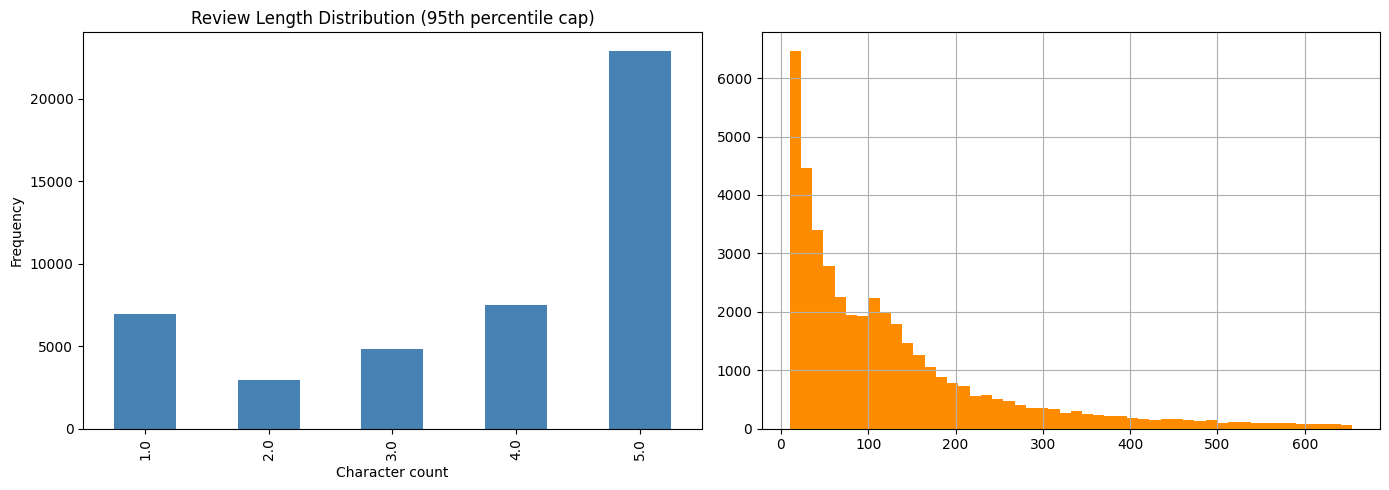

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rating distribution
df_clean['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("count")

#Text length distribution
cap = df_clean['text_length'].quantile(0.95)
df_clean[df_clean['text_length'] <= cap]['text_length'].hist(bins=50, ax=axes[1], color='darkorange')
axes[0].set_title("Review Length Distribution (95th percentile cap)")
axes[0].set_xlabel("Character count")
axes[0].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=150)
plt.show()

***TEXT PROCESSING FOR EMBEDDINGS***

In [17]:
#combine title and text into one field for embedding
df_clean['embedding_text'] = df_clean['title_clean'] + ". " + df_clean['text_clean']

#checking the result
print(df_clean[['title_clean', 'text_clean', 'embedding_text']].sample(3))

#confirmation of no nulls remaining in the new field
print("\nNulls in embedding_text:", df_clean['embedding_text'].isnull().sum())

                                             title_clean  \
34991                               Great song selection   
31747  There are no clear cut instructions on how to ...   
16077             It keeps on running when you close it.   

                                              text_clean  \
34991                                         Very happy   
31747  There are no clear cut instructions on how to ...   
16077  I hate wasting battery life on my Fire but, un...   

                                          embedding_text  
34991                   Great song selection. Very happy  
31747  There are no clear cut instructions on how to ...  
16077  It keeps on running when you close it.. I hate...  

Nulls in embedding_text: 0


In [20]:
model = SentenceTransformer('all-MiniLM-L6-v2')    
sample_texts = df_clean['embedding_text'].iloc[:5].tolist()

start = time.time()
test_embeddings = model.encode(sample_texts, show_progress_bar=True)
elapsed = time.time() - start

print(f"Encoded {len(sample_texts)} texts in {elapsed:.2f} seconds")
print(f"Embedding shape: {test_embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Encoded 5 texts in 0.26 seconds
Embedding shape: (5, 384)


In [21]:
df_clean.head(3)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase,date,text_length,text_clean,title_clean,embedding_text
0,1.0,malware,mcaffee IS malware,[],B07BFS3G7P,B0BQSK9QCF,AGCI7FAH4GL5FI65HYLKWTMFZ2CQ,1562182632076,0,False,2019-07-03 19:37:12.076,18,mcaffee IS malware,malware,malware. mcaffee IS malware
1,5.0,Lots of Fun,I love playing tapped out because it is fun to...,[],B00CTQ6SIG,B00CTQ6SIG,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1424120336000,0,True,2015-02-16 20:58:56.000,140,I love playing tapped out because it is fun to...,Lots of Fun,Lots of Fun. I love playing tapped out because...
2,5.0,Light Up The Dark,I love this flashlight app! It really illumin...,[],B0066WJLU6,B0066WJLU6,AHSPLDNW5OOUK2PLH7GXLACFBZNQ,1362399267000,0,True,2013-03-04 12:14:27.000,112,I love this flashlight app! It really illumina...,Light Up The Dark,Light Up The Dark. I love this flashlight app!...


In [20]:
#Get all the texts we are embedding
all_texts = df_clean['embedding_text'].tolist()

print(f"Encoding {len(all_texts)} reviews...")

#batch_size controls how many reviews get processed together-
# 64 is a good banc of speed and memory use on your machine

embeddings = model.encode(
    all_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True
)

elapsed = time.time() - start

print(f"\nDone! Encoded {len(all_texts)} reviews in {elapsed/60:.1f} minutes")
print(f"Embeddings shape: {embeddings.shape}")

#sae embeddings to the disk immediately - this is the slow step
np.save('reviews_embeddings.npy', embeddings)
print("Saved to the reviews_embeddings.npy")

Encoding 45121 reviews...


Batches:   0%|          | 0/706 [00:00<?, ?it/s]


Done! Encoded 45121 reviews in 73.4 minutes
Embeddings shape: (45121, 384)
Saved to the reviews_embeddings.npy


In [25]:
embeddings = np.load('reviews_embeddings.npy')
print("Embeddings shape:", embeddings.shape)
print("Number of reviews in df_clean:", len(df_clean))

#These two must match
assert embeddings.shape[0] == len(df_clean), "Mismatch! Row counts don't align"
print("Embeddings match dataset row count")

Embeddings shape: (45121, 384)
Number of reviews in df_clean: 45121
Embeddings match dataset row count


In [27]:
#connectingto our containerized Postgres
conn = psycopg2.connect(
    host="localhost",
    port=5433,
    dbname="amazon_search",
    user="mikaelson",
    password="devpassword"
)
conn.autocommit = True
cur = conn.cursor()

#Enable the pgvector extensioninside this database
cur.execute("CREATE EXTENSION IF NOT EXISTS vector;")

#Create a table: one row review, with embedding vector

cur.execute("""
    CREATE TABLE IF NOT EXISTS reviews (
        id SERIAL PRIMARY KEY,
        asin TEXT,
        title TEXT,
        review_text TEXT,
        rating FLOAT,
        embedding vector(384)
    );
""")

print("Connected and table created successfully")



Connected and table created successfully


In [29]:
#loading embeddings
embeddings = np.load('reviews_embeddings.npy')

#preparing data for bulk insert
records = []
for i, row in df_clean.iterrows():
    records.append((
        row['asin'],
        row['title_clean'],
        row['text_clean'],
        float(row['rating']),
        embeddings[i].tolist()  #pdvector accepts lists directly
    ))
print(f"Prepared {len(records)} records for insertion")

Prepared 45121 records for insertion


In [34]:
insert_query = """
    INSERT INTO reviews (asin, title, review_text, rating, embedding)
    VALUES %s
"""

execute_values(cur, insert_query, records, page_size=1000)
conn.commit()
print("Inserted {len(records)} reviews into the database")

Inserted {len(records)} reviews into the database


In [35]:
cur.execute("SELECT COUNT(*) FROM reviews;")
print("Rowsmin database:", cur.fetchone()[0])

Rowsmin database: 45121


In [36]:
cur.execute("""
    CREATE INDEX ON reviews
    USING ivfflat (embedding vector_cosine_ops)
    WITH (lists = 100);
""")
conn.commit()
print("Index created")

Index created


In [41]:
def search_reviews(query, top_k=5):
    #Converting the search query into the same embedding pace as our reviews
    query_embedding = model.encode(query).tolist()

    #Finding similar reviews using cosine distance
    cur.execute("""
        SELECT asin, title, review_text, rating,
               1 - (embedding <=> %s::vector) AS similarity
        FROM reviews
        ORDER BY embedding <=> %s::vector
        LIMIT %s;
    """, (query_embedding, query_embedding, top_k))

    results = cur.fetchall()

    for asin, title, text, rating, similarity in results:
        print(f"\n[{similarity:.3f}] {title} (rating: {rating})")
        print(f" {text[:150]}...")

    return results

search_reviews("app keeps crashing after update")


[0.674] crashing (rating: 1.0)
 It worked fine until it updated....

[0.664] help (rating: 1.0)
 Last update has royally broken this app....

[0.662] update fails (rating: 3.0)
 Update (4/29/15) keep failing. Very annoying. Otherwise great app!...

[0.611] Worst update EVER! App is now useless! (rating: 1.0)
 Latest update broke the app for Kindle Fire devices BIG time! Now the app is useless. Constant crashing every time you borrow a comic, return a comic,...

[0.602] A bit frustrating (rating: 4.0)
 I enjoy the game,but,I have had to uninstall,and reinstall it twice because it freezes up! Now it wants to update, but when I try, it doesn't open, bu...


[('B0094BB4TW',
  'crashing',
  'It worked fine until it updated.',
  1.0,
  0.673539141609101),
 ('B0059WTMLW',
  'help',
  'Last update has royally broken this app.',
  1.0,
  0.6643628678105564),
 ('B008XG1X18',
  'update fails',
  'Update (4/29/15) keep failing. Very annoying. Otherwise great app!',
  3.0,
  0.6622973084449815),
 ('B005VVSQU4',
  'Worst update EVER! App is now useless!',
  "Latest update broke the app for Kindle Fire devices BIG time! Now the app is useless. Constant crashing every time you borrow a comic, return a comic, or ever try to download one! Oh, and what's better, you have sign back in EVERY time it crashes, so like every 5 minutes. Stop fixing things that aren't broke! NIW your just fixing things until they do break!",
  1.0,
  0.6114776962114764),
 ('B074KC6ZFN',
  'A bit frustrating',
  "I enjoy the game,but,I have had to uninstall,and reinstall it twice because it freezes up! Now it wants to update, but when I try, it doesn't open, but returns to the s